# Image Classification with Logistic Regression

The MedMNIST dataset is licensed under Creative Commons Attribution 4.0 International (CC BY 4.0). The dataset is from the following paper:

* Jiancheng Yang, Rui Shi, Donglai Wei, Zequan Liu, Lin Zhao, Bilian Ke, Hanspeter Pfister, Bingbing Ni. "MedMNIST v2: A Large-Scale Lightweight Benchmark for 2D and 3D Biomedical Image Classification". arXiv preprint arXiv:2110.14795, 2021.
* Jiancheng Yang, Rui Shi, Bingbing Ni. "MedMNIST Classification Decathlon: A Lightweight AutoML Benchmark for Medical Image Analysis". IEEE 18th International Symposium on Biomedical Imaging (ISBI), 2021.

The MedMNIST dataset contains medical imaging data ranging from colonoscopy imaging to abdominal CT scans to breast ultrasounds.  There two main types of data formats that are used: 2 dimensional images and 3 dimensional.

----
## Install required packages and dataset

**Goal:** Install the necessary packages and dataset

*Note that this will take a few minutes to run...*

In [ ]:
# Terminal command for installing packages. pip is commonly used to install any python package.  Here, we pass in medmnist as the package name.  You can install any existing python packages using the command format pip install XXX, where XXX is the name of the desired package.
! pip install medmnist

# Medmnist package
import medmnist
from medmnist import INFO, Evaluator

%matplotlib inline
import IPython.core.display
# Setup output image format (Chrome works best)
IPython.core.display.set_matplotlib_formats("svg")

# Utlity packages
import os
import random
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, PrecisionRecallDisplay, RocCurveDisplay
import numpy as np
from sklearn import *
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.4/88.4 kB 959.4 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using ca

<ipython-input-1-5a7ba527ef0c>:11: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  IPython.core.display.set_matplotlib_formats("svg")


The following code chunk ensures that the MedMNIST data has been properly set up. This shows the current version and the source of the MedMNIST dataset.

In [ ]:
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

MedMNIST v3.0.1 @ https://github.com/MedMNIST/MedMNIST/


----
## Load and preprocess data

**Goal:** After installing the dataset (in the step above), we need to now load in the dataset so that we can use the dataset in our code.

*Note that there are multiple steps for this process...*


### Step 1: Specify dataset

There are many different possible datasets that we can use, so we need to specify the dataset we want to use (and other parameters needed to run a model on that dataset).

In [ ]:
data_flag = 'pathmnist'
# data_flag = 'breastmnist'
download = True

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

### Step 2: Load the data

Now that we have set up the parameters required to load the dataset we want, let's load the data. Run the next cell to load the dataset that we will use to train and test our model. *Note that this will take a few minutes...*


In [ ]:
# Transforms our data through tensor building and normalization (preprocessing step)
data_transform = transforms.Compose([
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean=[.5], std=[.5])
                                    ])

# Split the dataset into training and testing data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)
pil_dataset = DataClass(split='train', download=download)

# Load the data in the necessary format for the model
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

100%|██████████| 205615438/205615438 [00:09<00:00, 21651126.15it/s]


Using downloaded and verified file: /root/.medmnist/pathmnist.npz
Using downloaded and verified file: /root/.medmnist/pathmnist.npz


### Step 3: Summarize data

Let's take a quick look at the training and testing data we prepare for the analysis. We should have 89,996 data points for training and 7,180 data points for testing.

In [ ]:
print(train_dataset)

Dataset PathMNIST of size 28 (pathmnist)
    Number of datapoints: 89996
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
    Number of samples: {'train': 89996, 'val': 10004, 'test': 7180}
    Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K

In [ ]:
print(test_dataset)

Dataset PathMNIST of size 28 (pathmnist)
    Number of datapoints: 7180
    Root location: /root/.medmnist
    Split: test
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
    Number of samples: {'train': 89996, 'val': 10004, 'test': 7180}
    Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K i

Let's visualize a few data points. The dataset consists of image patches of tissues and their respective label (category). We expect to categorize the tissues to the type that they should belong to.

/usr/local/lib/python3.10/dist-packages/medmnist/utils.py:32: FutureWarning: `multichannel` is a deprecated argument name for `montage`. It will be removed in version 1.0. Please use `channel_axis` instead.
  montage_arr = skimage_montage(sel_img, multichannel=(n_channels == 3))


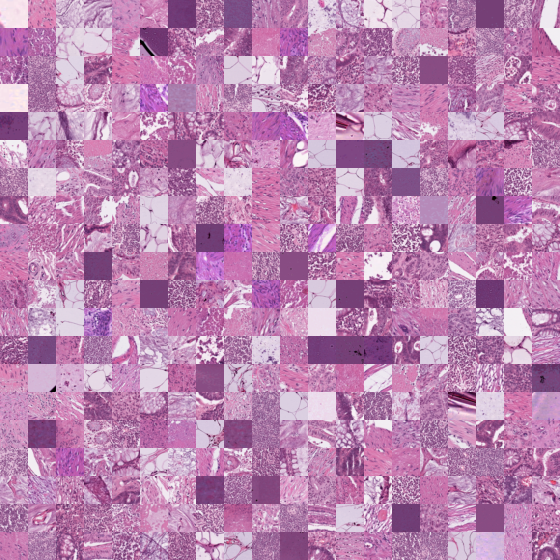

In [ ]:
"""
The .montage() function takes in a parameter called length, which allows you to
set the number of images per row and per column to output in a square montage.

This function is specific to the DataClass class. In this example, we have set
the parameter length to 20, and we can count 20 images as the side length of
the square montage.
"""

train_dataset.montage(length=20)

----
## Logistic regression to classify adipose vs. colon mucosa

Logistic regression is a supervised statistical model that predicts the probability of an event taking place. This means that the output of a logistic regression ranges between 0 and 1.

In this activity, we will predict whether an image shows tissue patches of adipose (body fat) or normal colon mucosa.

### Step 0: Hypothesis

***Question:*** How well do you think your model will perform on this task? Why?

***Answer:*** Write your answer here (double click on cell to type)




### Step 1: Prepare dataset

We need to create a dataset that consists only 2 labels: tissue patches of adipose (body fat) or normal colon mucosa. Adipose tissue is labeled as '0' and normal colon mucosa is labeled as '6'. There should be 17,252 images in the training dataset and 2,079 in the test dataset.

In [ ]:
# Extract images that are adipose tissues (label 0) or normal colon mucosa (label 6) using list comprehensions
subset_train_images = train_dataset.imgs[[i for i, x in enumerate(np.logical_or(train_dataset.labels == 0, train_dataset.labels == 6)) if x]]
subset_test_images = test_dataset.imgs[[i for i, x in enumerate(np.logical_or(test_dataset.labels == 0, test_dataset.labels == 6)) if x]]

In [ ]:
# Extract labels that are adipose tissues (label 0) or normal colon mucosa (label 6) using list comprehensions
subset_train_labels = train_dataset.labels[[i for i, x in enumerate(np.logical_or(train_dataset.labels == 0, train_dataset.labels == 6)) if x]]
subset_test_labels = test_dataset.labels[[i for i, x in enumerate(np.logical_or(test_dataset.labels == 0, test_dataset.labels == 6)) if x]]

We need to relabel the images to be either 0 and 1 because the logistic regression can only predict values between 0 and 1. Let's give the label 0 to adipose tissue and 1 for normal colon mucosa.

In [ ]:
# Subset the data using a conditional statement in the brackets, and assign the new labels
subset_train_labels[subset_train_labels == 0] = int(0)
subset_train_labels[subset_train_labels == 6] = int(1)
subset_test_labels[subset_test_labels == 0] = int(0)
subset_test_labels[subset_test_labels == 6] = int(1)

Let's check that our data is ready:



Label: [0]
The actual image:


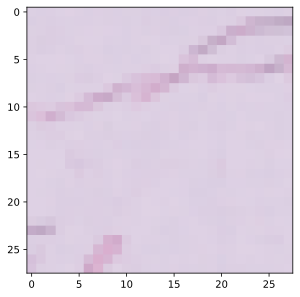

In [ ]:
# This image in the training dataset should be adipose tissue
plt.ion() # Activating the plot
print('Label: ' + str(subset_train_labels[0]))
print('The actual image:')
plt.imshow(subset_train_images[0]) # Display the image
plt.show() # Visualizes the image through the output

Label: [1]
The actual image:


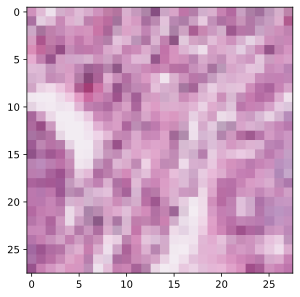

In [ ]:
# This image in the training dataset should be colon mucosa
plt.ion() # Activating the plot
print('Label: ' + str(subset_train_labels[100]))
print('The actual image:')
plt.imshow(subset_train_images[100]) # Display the image
plt.show() # Visualizes the image through the output

Label: [0]
The actual image:


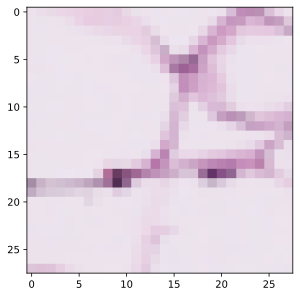

In [ ]:
# This image in the testing dataset should be adipose tissue
plt.ion() # Activating the plot
print('Label: ' + str(subset_test_labels[0]))
print('The actual image:')
plt.imshow(subset_test_images[0]) # Display the image
plt.show() # Visualizes the image through the output

Label: [1]
The actual image:


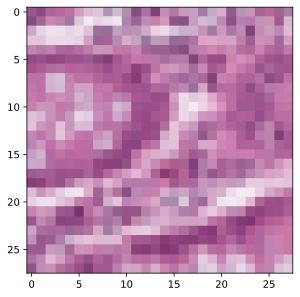

In [ ]:
# This image in the testing dataset should be colon mucosa
plt.ion() # Activating the plot
print('Label: ' + str(subset_test_labels[100]))
print('The actual image:')
plt.imshow(subset_test_images[100]) # Display the image
plt.show() # Visualizes the image through the output

Finally, we need to adjust the dimensions of the dataset from a 3D array into a 2D array (for the logistic regression model). We can use numpy to reshape the train and test images.

In [ ]:
# Training data
nsamples, nx, ny, nz = subset_train_images.shape
subset_train_images_reshaped = subset_train_images.reshape((nsamples, nx * ny * nz))

In [ ]:
# Testing data
nsamples, nx, ny, nz = subset_test_images.shape
subset_test_images_reshaped = subset_test_images.reshape((nsamples, nx * ny * nz))

### Step 2: Set up model

We will use the implementation of logistic regression in *sklearn*, which is a popular machine learning package.

In [ ]:
# Since our sample size is large, we use the solver 'lbfgs'
logreg = linear_model.LogisticRegression(solver = 'lbfgs', max_iter = 10000)

### Step 3: Train model

Time to fit our model on the training data (a.k.a. train the model)!

*Note that this will take about 15 minutes (or longer, depending on the laptop)...*

In [ ]:
fit_model = logreg.fit(subset_train_images_reshaped, subset_train_labels)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Step 4: Test model

After training the model, we can test how well it performs on the testing data.

In [ ]:
# Generate prediction on one of the test data points
predicted_label = fit_model.predict(subset_test_images[123].reshape(1, -1))
print("Predicted label for subset_test_images[123]:", predicted_label)

Predicted label for subset_test_images[123]: [0]


Label: [0]
The actual image:


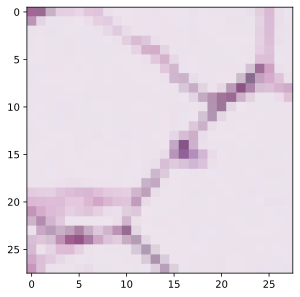

In [ ]:
# Visualize the subset_test_images[123]
# Does the actual label match the logistic regression's prediction?

plt.ion()
print('Label: ' + str(subset_test_labels[123]))
print('The actual image:')
plt.imshow(subset_test_images[123])
plt.show()

We want to calculate how well the logistic regression performs on the entire test dataset, not just on one data point. Let's calculate the accuracy of the logistic regression model on the test dataset. This is defined as the proportion of images in the test dataset that are correctly classified by the logistic regression model.

In [ ]:
# Generate predictions on the entire test dataset
predicted_labels = logreg.predict(subset_test_images_reshaped)

# Calculate accuracy on the test dataset
accuracy = metrics.accuracy_score(subset_test_labels, predicted_labels)
print("Testing accuracy =", accuracy)

Testing accuracy = 0.9374699374699375


***Question:*** Based on the calculated testing accuracy, was the logistic regression successful or unsuccessful in classifying the images of adipose tissue and colon mucosa? Why do you think it was successful (or unsuccessful)?

***Answer:*** Write your answer here (double click on cell to type)





Plot ROC and precision-recall curves

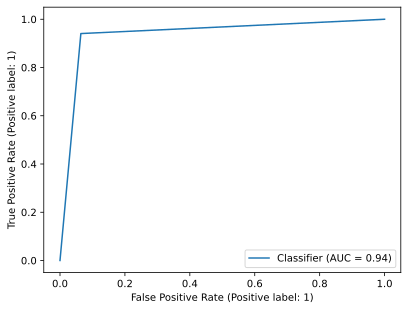

In [ ]:
# Plot ROC curve
RocCurveDisplay.from_predictions(subset_test_labels, predicted_labels)

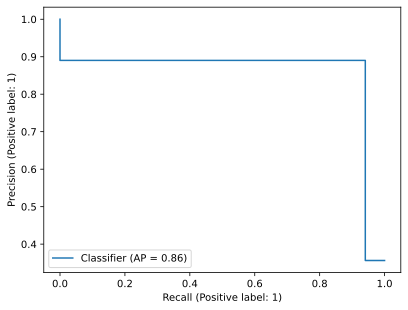

In [ ]:
# Plot precision-recall curve
PrecisionRecallDisplay.from_predictions(subset_test_labels, predicted_labels)

Calculate and visualize the confusion matrix of the logistic regression model on the test dataset.

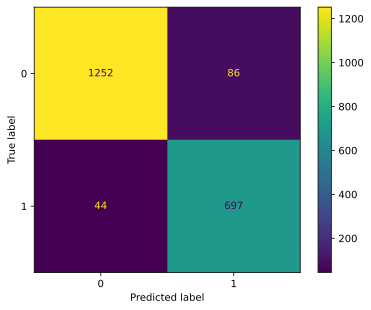

In [ ]:
# Compute confusion matrix

cm = confusion_matrix(subset_test_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

***Question:*** Based on the confusion matrix, would you be comfortable with deploying this model in hospitals/clinics?

***Answer:*** Write your answer here (double click on cell to type)

----
## Build your own logistic regression model

Choose two other categories in the dataset to train your own logistic regression model. For example, you can try to differentiate the images of normal colon mucosa vs. colorectal adenocarcinoma epithelium (colon cancer tissue).

### Step 0: Hypothesis

***Question:*** How do you think your model's accuracy will compare against the model used to differentiate between adipose tissue and colon mucosa (higher, lower, or the same accuracy)? Why?

***Answer:*** Write your answer here (double click on cell to type)




### Step 1: Prepare dataset

Create two variables containing the new images and labels by filtering for your two categories of images.

For the training dataset, you may call your new variables `new_train_images` and `new_train_labels`. For the testing dataset, you may call your new variables `new_test_images` and `new_test_labels`.

In [ ]:
# Select images of your two categories in the training datset
new_train_images = train_dataset.imgs[[]] # Fill in the brackets
new_train_labels = train_dataset.labels[[]] # Fill in the brackets

In [ ]:
# Select images of your two categories in the testing datset
new_test_images = test_dataset.imgs[[]] # Fill in the brackets
new_test_labels = test_dataset.labels[[]] # Fill in the brackets

The logistic regression model only accepts 0 or 1 as labels. So, we need to relabel the dataset to be either 0 or 1. Here, let's label normal colon mucosa as 0 and colorectal adenocarcinoma epithelium as 1.

In [ ]:
# Subset the data using a conditional statement in the brackets, and assign the new labels
# Write code here

Finally, we need to adjust the dimensions of the dataset from a 3D array into a 2D array (for the logistic regression model). We can use numpy to reshape the train and test images.

In [ ]:
# Reshape the training data
# Write code here

In [ ]:
# Reshape the testing data
# Write code here

### Step 2: Set up model

Select your logistic regression model from *sklearn*.

In [ ]:
# Write code here to select logistic regression model

### Step 3: Train model

Time to fit our model on the training data (a.k.a. train the model)! Use the selected model to fit the data using your training sets:

In [ ]:
# Write code here to fit the logistic regression model using the training set

### Step 4: Test model

After training the model, we can test how well it performs on the testing data.

In [ ]:
# Write code here to generate prediction on one of the test data points

In [ ]:
# Visualize one of the images
# Does the actual label match the logistic regression's prediction?

# Write code here

Calculate the accuracy of the logistic regression model on the test dataset.

In [ ]:
# Generate predictions on the entire test dataset
# Write code here

# Calculate accuracy on the test dataset
# Write code here
accuracy = 0 # Replace the 0 with the appropriate function
print("Testing accuracy =", accuracy)

Testing accuracy = 0


***Question:*** Based on the calculated testing accuracy, was the logistic regression successful or unsuccessful in classifying the images of the two categories? Why do you think it was successful (or unsuccessful)?

***Answer:*** Write your answer here (double click on cell to type)

Plot ROC and precision-recall curves

In [ ]:
# Plot ROC curve
# Write code here

In [ ]:
# Plot precision-recall curve
# Write code here

Calculate and visualize the confusion matrix of the logistic regression model on the test dataset.

In [ ]:
# Compute confusion matrix
# Write code here

***Question:*** Based on the confusion matrix, would you be comfortable with deploying this model in hospitals/clinics?

***Answer:*** Write your answer here (double click on cell to type)